# Model 1b - Decision Tree


A single, fully interpretable tree. It is also the building block of Random Forest, XGBoost and LightGBM, so it helps explain why ensembles work.

> **How to run:** first set `DATA_FRAC = 0.1` to check that everything works (a few minutes), then set it to `1.0` and *Run All* for the real results.
> Everything here uses the shared code in `src/` - same split, same 5 folds, same metrics as the other members.

## 1. Setup and data

In [1]:
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
from common import *
from sklearn.tree import DecisionTreeClassifier, plot_tree

NAME = "Decision Tree"

# ---- run configuration ---------------------------------------------------------------------------
DATA_FRAC        = 1.0    # share of TRAINING patients used in this notebook (0.1 = quick check run)
EXP_FRAC         = 0.3    # share of patients used for the small experiments in section 4
TUNE_SAMPLE_FRAC = 0.3    # share of patients used DURING the search (the best model is refitted on ALL data)
N_ITER           = 24     # candidates tried by random / halving search
SEARCH_METHOD    = "grid"   # "random" | "grid" | "halving"
# --------------------------------------------------------------------------------------------------
reset_log(NAME)

In [2]:
X_train, X_test, y_train, y_test, g_train, cv, class_names = load_and_split()
X_train, y_train, g_train = patient_subsample(X_train, y_train, g_train, DATA_FRAC)
X_exp, y_exp, g_exp = patient_subsample(X_train, y_train, g_train, EXP_FRAC)
print("train", X_train.shape, "| test", X_test.shape, "| classes", class_names)
pd.Series(y_train).map(dict(enumerate(class_names))).value_counts(normalize=True).round(3)

train (79541, 50) | test (19802, 50) | classes ['<30', '>30', 'NO']


NO     0.528
>30    0.357
<30    0.114
Name: proportion, dtype: float64

## 2. Why this model? (algorithm selection and justification)

- **Task fit:** handles multiclass natively and produces human-readable rules ("if previous inpatient visits > 2 and ...").
- **Data fit:** no scaling needed, robust to outliers, handles mixed features. **Weaknesses:** unpruned trees over-fit badly and are unstable; a single tree is rarely the most accurate.
- **Role in the project:** an interpretable comparator and the concept behind the ensembles (bagging = Random Forest, boosting = XGBoost / LightGBM).

## 3. Baseline model and validation strategy
- **Validation:** 5-fold `StratifiedGroupKFold` on the training set, grouped by `patient_nbr` (a patient never appears in both the training and validation part of a fold) and stratified (the rare `<30` class, about 11%, appears in every fold). The folds are fixed (`random_state=42`) and identical for every model.
- **Preprocessing inside the pipeline:** imputation, scaling and one-hot encoding are refitted on the training part of each fold, so nothing leaks from the validation part.
- **Imbalance:** handled with class weights, not by resampling (SMOTE works poorly on ~2,400 sparse one-hot columns).
- **Main metric: macro-F1** (every class counts equally). Accuracy is misleading here because always predicting `NO` already scores about 55%. We also track macro-recall, ROC-AUC (one-vs-rest) and PR-AUC / recall for the `<30` class.
- The **test set is not touched** until section 6.

In [3]:
def make_pipe(**kw):
    params = dict(class_weight="balanced", random_state=RANDOM_STATE)
    params.update(kw)
    return Pipeline([("pre", make_preprocessor(scale=False)),
                     ("m", DecisionTreeClassifier(**params))])


pipe = make_pipe()
baseline = cv_evaluate(pipe, X_train, y_train, g_train, cv)
pd.Series({k: round(v, 4) for k, v in baseline.items() if not isinstance(v, list)})

cv_macro_f1            0.3851
cv_weighted_f1         0.4694
cv_macro_recall        0.3864
cv_macro_precision     0.3846
cv_accuracy            0.4663
cv_roc_auc_ovr         0.5427
cv_pr_auc_lt30         0.1238
cv_recall_lt30         0.1884
cv_precision_lt30      0.1642
cv_f1_lt30             0.1755
cv_macro_f1_std        0.0030
cv_pr_auc_lt30_std     0.0007
train_macro_f1         1.0000
fit_time_s            29.3532
dtype: float64

### Baseline observations
_Write 2-3 sentences: How does the baseline compare with the majority-class score (macro-F1 about 0.23)? Is there a big gap between `train_macro_f1` and `cv_macro_f1` (over-fitting)?_

## 4. Experiments - understanding why the model behaves the way it does
Each experiment is cross-validated with the same folds on a patient sample (`EXP_FRAC`) and is saved automatically to `outputs/results/<model>_experiments.csv` (this is your experiment record for the report).

### Experiment 1
**Tree depth** - the classic over-fitting curve. An unrestricted tree memorises the training data (train F1 near 1.0).

[max_depth] max_depth=2: macro-F1=0.3516 (train 0.3557)
[max_depth] max_depth=3: macro-F1=0.3782 (train 0.3878)
[max_depth] max_depth=5: macro-F1=0.3926 (train 0.4098)
[max_depth] max_depth=8: macro-F1=0.3995 (train 0.4496)
[max_depth] max_depth=12: macro-F1=0.4034 (train 0.5318)
[max_depth] max_depth=20: macro-F1=0.3954 (train 0.7271)
[max_depth] max_depth=None: macro-F1=0.3812 (train 1.0000)


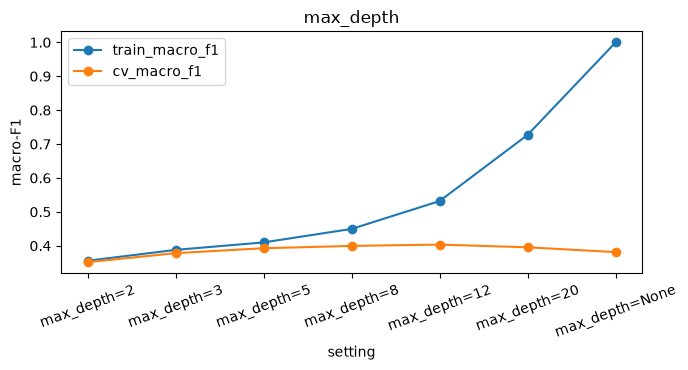

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,max_depth,max_depth=2,0.3516,0.3557,0.4200,0.6070,0.1572,0.1976
1,max_depth,max_depth=3,0.3782,0.3878,0.4203,0.6212,0.1695,0.2184
2,max_depth,max_depth=5,0.3926,0.4098,0.4307,0.6250,0.1739,0.3076
3,max_depth,max_depth=8,0.3995,0.4496,0.4257,0.6117,0.1602,0.5548
4,max_depth,max_depth=12,0.4034,0.5318,0.4183,0.5894,0.1453,0.9954
5,max_depth,max_depth=20,0.3954,0.7271,0.4048,0.5526,0.1301,2.2494
6,max_depth,max_depth=None,0.3812,1.0000,0.3821,0.5397,0.1202,3.4750


In [4]:
sweep(NAME, "max_depth", [2, 3, 5, 8, 12, 20, None], lambda v: make_pipe(max_depth=v), X_exp, y_exp, g_exp, cv)

**Observation:** _(what did you see and why? one or two sentences)_

### Experiment 2
**Minimum samples per leaf** - a second way to stop the tree memorising small groups.

[min_samples_leaf] min_samples_leaf=1: macro-F1=0.4034 (train 0.5318)
[min_samples_leaf] min_samples_leaf=5: macro-F1=0.3902 (train 0.5083)
[min_samples_leaf] min_samples_leaf=20: macro-F1=0.3827 (train 0.4752)
[min_samples_leaf] min_samples_leaf=50: macro-F1=0.3849 (train 0.4570)
[min_samples_leaf] min_samples_leaf=100: macro-F1=0.3960 (train 0.4438)


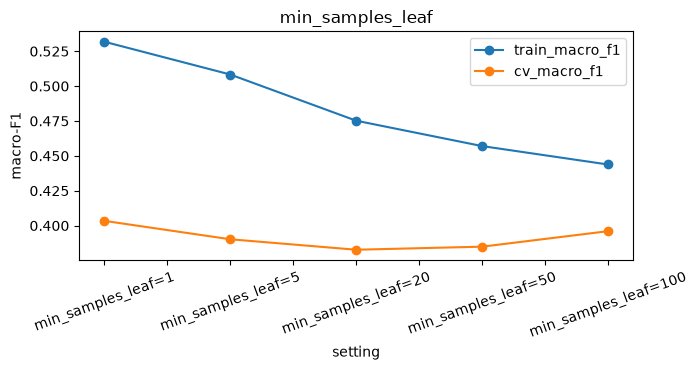

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,min_samples_leaf,min_samples_leaf=1,0.4034,0.5318,0.4183,0.5894,0.1453,0.9175
1,min_samples_leaf,min_samples_leaf=5,0.3902,0.5083,0.4125,0.5893,0.1460,0.8910
2,min_samples_leaf,min_samples_leaf=20,0.3827,0.4752,0.4118,0.5928,0.1520,0.8074
3,min_samples_leaf,min_samples_leaf=50,0.3849,0.4570,0.4149,0.5983,0.1575,0.6937
4,min_samples_leaf,min_samples_leaf=100,0.3960,0.4438,0.4251,0.6148,0.1696,0.5263


In [5]:
sweep(NAME, "min_samples_leaf", [1, 5, 20, 50, 100], lambda v: make_pipe(min_samples_leaf=v, max_depth=12), X_exp, y_exp, g_exp, cv)

**Observation:** _(what did you see and why? one or two sentences)_

### Experiment 3
**Cost-complexity pruning (`ccp_alpha`)** - grow a full tree, then prune weak branches.

[ccp_alpha] ccp_alpha=0.0: macro-F1=0.4034 (train 0.5318)
[ccp_alpha] ccp_alpha=0.0001: macro-F1=0.4041 (train 0.5188)
[ccp_alpha] ccp_alpha=0.0005: macro-F1=0.4096 (train 0.4202)
[ccp_alpha] ccp_alpha=0.001: macro-F1=0.3831 (train 0.3900)
[ccp_alpha] ccp_alpha=0.005: macro-F1=0.3107 (train 0.3107)


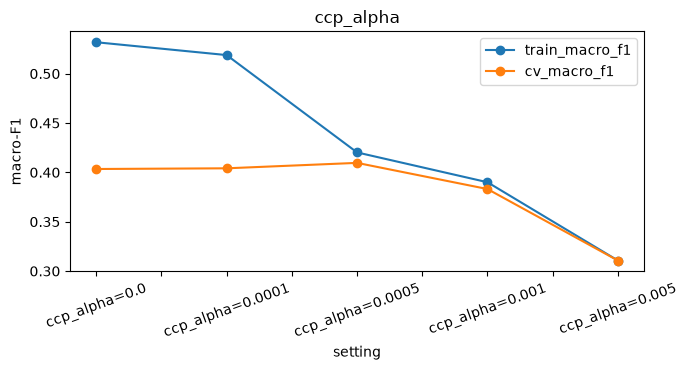

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,ccp_alpha,ccp_alpha=0.0,0.4034,0.5318,0.4183,0.5894,0.1453,1.1261
1,ccp_alpha,ccp_alpha=0.0001,0.4041,0.5188,0.4193,0.5912,0.1445,1.1327
2,ccp_alpha,ccp_alpha=0.0005,0.4096,0.4202,0.4334,0.6295,0.1782,1.2500
3,ccp_alpha,ccp_alpha=0.001,0.3831,0.3900,0.4239,0.6230,0.1699,0.9855
4,ccp_alpha,ccp_alpha=0.005,0.3107,0.3107,0.4212,0.5932,0.1395,0.9749


In [6]:
sweep(NAME, "ccp_alpha", [0.0, 0.0001, 0.0005, 0.001, 0.005], lambda v: make_pipe(ccp_alpha=v, max_depth=12), X_exp, y_exp, g_exp, cv)

**Observation:** _(what did you see and why? one or two sentences)_

### Experiment 4
**Class weights vs none** - effect of handling imbalance on macro-F1 and accuracy.

In [7]:
for cw in ["balanced", None]:
    run_experiment(NAME, "Class weight", f"class_weight={cw}", make_pipe(class_weight=cw, max_depth=8), X_exp, y_exp, g_exp, cv)
show_experiments(NAME, "Class weight")

[Class weight] class_weight=balanced: macro-F1=0.3995 (train 0.4496)
[Class weight] class_weight=None: macro-F1=0.3807 (train 0.4345)


,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,Class weight,class_weight=balanced,0.3995,0.4496,0.4257,0.6117,0.1602,0.4959
1,Class weight,class_weight=None,0.3807,0.4345,0.3990,0.6287,0.1729,0.4918


**Observation:** _(what did you see and why? one or two sentences)_

## 5. Hyper-parameter tuning (Stage 7)
**Search strategy:** **Grid search on a reduced grid** (4 depths x 3 leaf sizes x 2 pruning values = 24 combinations). The space is small and discrete, so grid search is exhaustive and reproducible; the search runs on a patient sample for speed.

Scoring is **macro-F1** with the same grouped folds. To keep the search fast, it runs on `TUNE_SAMPLE_FRAC` of the patients and the best configuration is then **refitted on all training data**. The tuned model is re-evaluated with the full 5-fold CV so that baseline and tuned scores are directly comparable.

In [8]:
space = {"m__max_depth": [4, 6, 8, 12],
         "m__min_samples_leaf": [10, 30, 100],
         "m__ccp_alpha": [0.0, 0.0005]}


tune_res = tune(pipe, space, X_train, y_train, g_train, cv,
                method=SEARCH_METHOD, n_iter=N_ITER, sample_frac=TUNE_SAMPLE_FRAC)
print("Best parameters:", tune_res.best_params_)
print(f"Search took {tune_res.search_time_s/60:.1f} min")
top_configs(tune_res)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'m__ccp_alpha': 0.0005, 'm__max_depth': 6, 'm__min_samples_leaf': 100}
Search took 1.0 min


,param_m__ccp_alpha,param_m__max_depth,param_m__min_samples_leaf,mean_test_score,std_test_score
17,0.0005,6,100,0.4129,0.0147
15,0.0005,6,10,0.4114,0.0153
20,0.0005,8,100,0.4110,0.0159
23,0.0005,12,100,0.4110,0.0159
16,0.0005,6,30,0.4110,0.0146


In [9]:
tuned = cv_evaluate(tune_res.best_estimator_, X_train, y_train, g_train, cv)   # full 5-fold CV, comparable with baseline
compare_table(baseline, tuned)

,baseline,tuned,change
CV macro-F1 (main metric),0.3851,0.4066,0.0214
CV macro-recall,0.3864,0.4405,0.0542
CV accuracy,0.4663,0.4858,0.0195
"CV ROC-AUC (OvR, macro)",0.5427,0.6302,0.0875
CV PR-AUC for <30,0.1238,0.1878,0.0640
CV recall for <30,0.1884,0.4111,0.2227
Train macro-F1 (over-fit check),1.0000,0.4075,-0.5925
Fit time per fold (s),29.3532,1.2947,-28.0585


**Observation:** _Did tuning help? By how much compared with the fold-to-fold spread (`cv_macro_f1_std`)? Which parameter mattered most?_

## 6. Final evaluation on the untouched test set (reported once)
The final model of the project is chosen later, in `compare_models.ipynb`, by **CV score - not by test score**.

              precision    recall  f1-score   support

         <30      0.198     0.343     0.251      2216
         >30      0.431     0.301     0.354      7090
          NO      0.632     0.663     0.647     10496

    accuracy                          0.497     19802
   macro avg      0.420     0.436     0.417     19802
weighted avg      0.512     0.497     0.498     19802



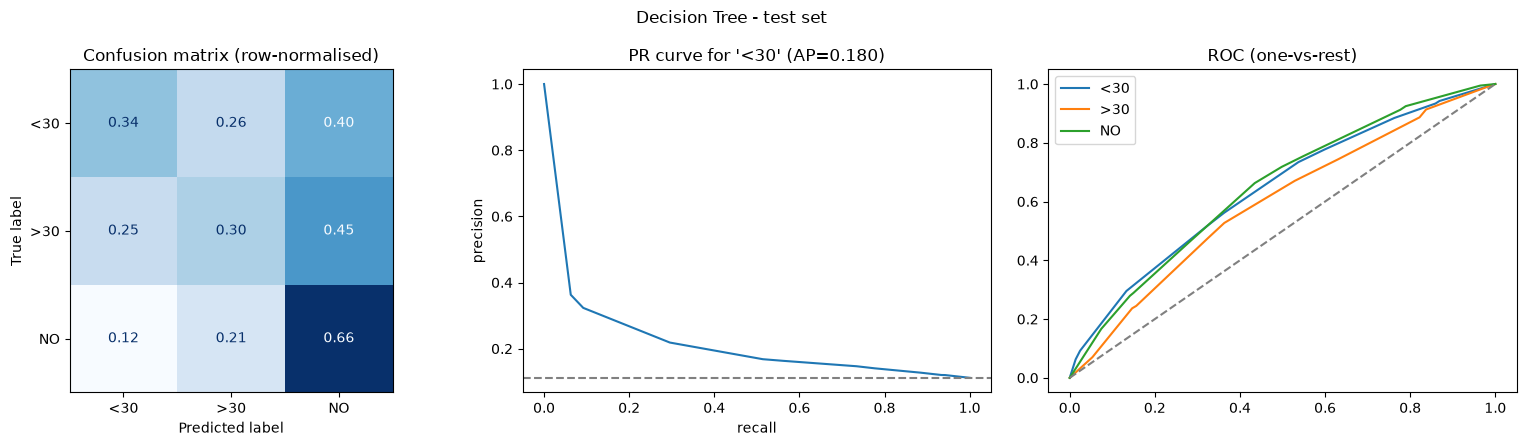

Saved outputs/results/decision_tree.json and outputs/models/decision_tree.joblib


In [10]:
result = finalize(NAME, baseline, tuned, tune_res, X_test, y_test, class_names)

## 7. Interpretation

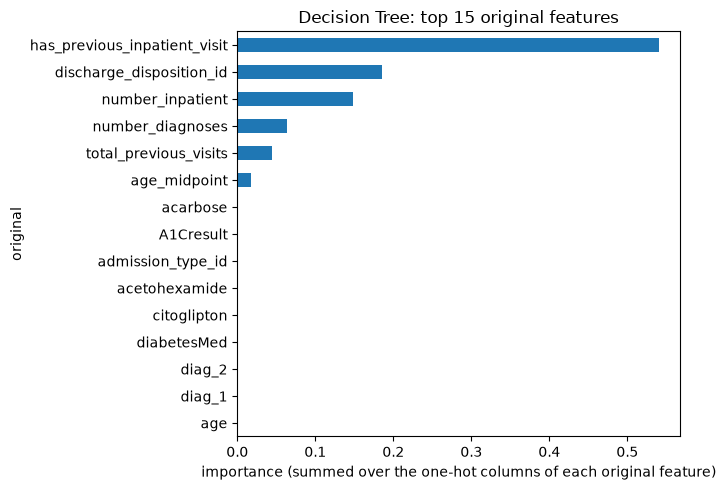

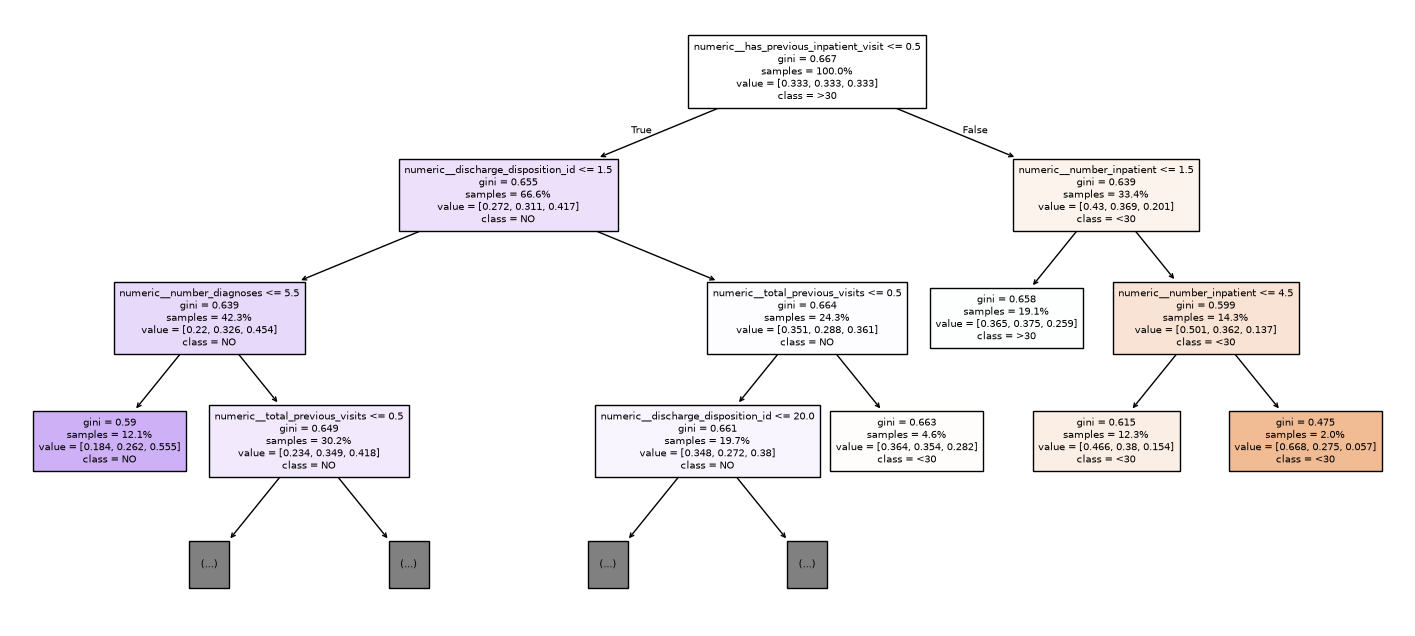

In [11]:
best = tune_res.best_estimator_
tbl = feature_importance_table(best, X_train.columns)
top = top_original_features(tbl, 15)
plot_top_features(top, f"{NAME}: top 15 original features", NAME)
top.round(4)

# The first levels of the tuned tree = the most important decision rules
best = tune_res.best_estimator_
names = best.named_steps["pre"].get_feature_names_out()
plt.figure(figsize=(18, 8))
plot_tree(best.named_steps["m"], max_depth=3, feature_names=names, class_names=class_names,
          filled=True, fontsize=7, proportion=True)
plt.savefig(FIGS_DIR / "decision_tree_top_levels.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Observations and viva preparation
**Write your own conclusions here (they go into the report):**
- Where does this model perform well / badly, per class? Why?
- What did the experiments show about over-fitting, imbalance and feature choices?
- Do the important features make clinical sense?

**Be ready to answer:**

- Why does an unrestricted tree over-fit? What do `max_depth`, `min_samples_leaf` and `ccp_alpha` do?
- Why is a single tree unstable, and how do Random Forest and boosting fix that?
- Read the top of the plotted tree: what is the first split and why?
- How would a hospital use these rules?